In [14]:
# capstone project -- function 3 (3D), week N

import numpy as np
import matplotlib.pyplot as plt

# Delaunay: convex-hull membership check for the proposal.
# ConvexHull: hull volume, to quantify how loose the bounding box is.
from scipy.spatial import Delaunay, ConvexHull

from bayes_tools import (
    fitting,
    normalize, initial_bounds, validate_bounds_consistency,
    generate_next_point, ei_acquisition, max_variance_acquisition,
    append_observations, compute_iteration_diagnostics,
    fit_gp, get_length_scales, loo_predictions,
    compare_xi_proposals, print_xi_comparison,
    backtest_acquisitions, print_backtest_summary,
)
from viz_tools import (
    plot_nd_slices, plot_loo_calibration, plot_xi_sensitivity,
    plot_acquisition_backtest,
    plot_convergence, plot_acquisition_decay, plot_uncertainty_shrinkage,
    plot_step_distance,
)

# Function 3

3D

In [15]:
X_initial = np.load("initial_data/function_3/initial_inputs.npy")
y_initial = np.load("initial_data/function_3/initial_outputs.npy")
n_initial = len(y_initial)
D = X_initial.shape[1]

assert D == 3, f"Expected a 3D problem, got {D}D input -- check the loaded file."

# Once, at the very start of the capstone:
new_X = np.empty((0, D))
new_y = np.empty((0,))

## Update this once per week

Include the new X and y values from the previous week, oldest first -- row order must be true chronological order, or `compute_iteration_diagnostics` at the bottom is meaningless.

One observation is recorded so far. It predates the switch away from PI (the old version of this notebook proposed with `pi`/`xi=0.01`), so the history is mixed in terms of what chose each point. The diagnostics section explains how the replay handles that.

In [16]:
# Append last week's result BEFORE proposing this week's point, e.g.:
#
# new_X, new_y = append_observations(new_X, new_y, x_next, the_result_you_got)

new_X = np.array([
    [0.270875, 0.2582, 0.418474],       # week 2
    [0.492581, 0.611593, 0.669818],     # week 3 -- the max_variance proposal
])

new_y = np.array([
    -0.05641777085561445,
    -0.1100596532042417,
])

print("observations collected so far:", len(new_y))
print("latest y: %.6f | best before it: %.6f (change %+.6f)"
      % (new_y[-1], max(y_initial.max(), new_y[0]),
         new_y[-1] - max(y_initial.max(), new_y[0])))


observations collected so far: 2
latest y: -0.110060 | best before it: -0.034835 (change -0.075224)


## Build the full dataset (initial + everything collected so far)

In [17]:
X, y = append_observations(X_initial, y_initial, new_X, new_y)

print("X_initial shape:", X_initial.shape, "| y_initial shape:", y_initial.shape)
print("new_X shape:     ", new_X.shape, "| new_y shape:     ", new_y.shape)
print("combined X shape:", X.shape, "| combined y shape:", y.shape)

print("\nX range per dimension:")
print("  min:", X.min(axis=0))
print("  max:", X.max(axis=0))
print("y range:", y.min(), "to", y.max())

# The project-standard bounds. X is known to never be negative, so
# lower_limit=0.0 is mandatory -- without it this function's padded bounds
# start at about -0.87 / -0.50 / -0.86, which are impossible inputs.
bounds_standard = initial_bounds(X_initial, pad_fraction=1.0, lower_limit=0.0)
validate_bounds_consistency(X, bounds_standard)

# DELIBERATE DEVIATION THIS WEEK (see header): search only the axis-aligned
# bounding box of the observed data, so no coordinate can exceed the range
# already seen on its own axis. NOTE this is the bounding BOX, not the convex
# hull -- a corner of the box can still be far outside the data cloud, so this
# constrains extrapolation without eliminating it. The proposal cell checks
# convex-hull membership separately. Revert to bounds_standard once the GP has
# reason to prefer a direction along x0/x1, or the search can never expand
# beyond the initial batch's footprint.
bounds_box = np.column_stack([X.min(axis=0), X.max(axis=0)])
validate_bounds_consistency(X, bounds_box)

bounds = bounds_box

print("\nstandard bounds (pad_fraction=1.0):\n", np.round(bounds_standard, 4))
print("\nobserved bounding box (USED THIS WEEK):\n", np.round(bounds_box, 4))

print("\nfraction of each standard-bounds axis actually covered by data:")
frac = 1.0
for d in range(D):
    f = (X[:, d].max() - X[:, d].min()) / (bounds_standard[d, 1] - bounds_standard[d, 0])
    frac *= f
    print(f"  x{d}: {f:.1%}")
print(f"  -> {frac:.1%} of the standard box by volume; the rest is extrapolation")

# How loose is the bounding box as a stand-in for "where the data is"? In 3D
# with few points the cloud is nearly all surface, so the box overstates it.
hull = Delaunay(X)
box_volume = float(np.prod(bounds_box[:, 1] - bounds_box[:, 0]))
try:
    ch_volume = ConvexHull(X).volume
    print(f"\nbounding box volume: {box_volume:.5f} | true convex hull volume: {ch_volume:.5f}"
          f" ({ch_volume / box_volume:.1%} of the box)")
except Exception as exc:  # degenerate point set -- not fatal, just skip
    print("\nconvex hull volume unavailable:", exc)

xi_frac = 0.01 / (y.max() - y.min())
print(f"\nxi=0.01 is {xi_frac:.2%} of the y spread "
      f"-> {'scaling NOT needed' if 0.001 <= xi_frac <= 0.1 else 'CONSIDER y-scaling'}")

X_initial shape: (15, 3) | y_initial shape: (15,)
new_X shape:      (2, 3) | new_y shape:      (2,)
combined X shape: (17, 3) | combined y shape: (17,)

X range per dimension:
  min: [0.04680895 0.21991724 0.06608864]
  max: [0.96599485 0.94135983 0.99088187]
y range: -0.3989255131463011 to -0.034835313350078584

standard bounds (pad_fraction=1.0):
 [[0.     1.8852]
 [0.     1.6628]
 [0.     1.9157]]

observed bounding box (USED THIS WEEK):
 [[0.0468 0.966 ]
 [0.2199 0.9414]
 [0.0661 0.9909]]

fraction of each standard-bounds axis actually covered by data:
  x0: 48.8%
  x1: 43.4%
  x2: 48.3%
  -> 10.2% of the standard box by volume; the rest is extrapolation

bounding box volume: 0.61327 | true convex hull volume: 0.21164 (34.5% of the box)

xi=0.01 is 2.75% of the y spread -> scaling NOT needed


## Backtest acquisition functions (using only data already collected)

A weak, free check on acquisition family: repeatedly split the data into a "seed" set (fits the GP) and a held-out "candidate" set (true y known, hidden from the fit), then see which config would have picked the best candidate most often. No new evaluations spent.

**Expect `max_variance` to come last, and expect that not to matter.** The metric scores recognition of points whose true `y` is already known, which is an exploitation task -- it rewards whatever ranks closest to the GP posterior mean and gives no credit for reducing uncertainty. A pure uncertainty-seeker is therefore penalised by construction, so this table cannot be used to argue against this week's choice. See the header.

The ordering among the *other* configs is weak too: the top four sit within about 0.014 with near-identical median regret (PI and EI are separated by 0.00005), and on function 2 the leader changed when a single observation was added.

Note these numbers move with the bounds, since the bounds set the input normalisation the GP is fit on -- they'll differ from a week run on the standard padded bounds. Don't compare across bounds choices.

LIMITATION: this only tests recognition of good points *already in the dataset*. It cannot test which config is best at proposing a genuinely new location, since there's no ground truth for that without a real evaluation -- which is exactly the question that matters this week. Kept because it's cheap and becomes informative later, once there are more points and the goal shifts to drilling in.

[fitting: acquisition backtest, 50 splits] 108 warnings held back, 4 distinct:
    37 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
    35 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
    26 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
    10 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
      config |  mean regret |  median regret |  mean picked y
-------------------------------------------------------------
     exploit |      0.03498 |        0.02158 |       -0.07288
      ucb_k1 |      0.03717 |        0.02158 |       -0.07507
    ei_xi001 |      0.04528 |        0.02175 |       -0.08318
    pi_xi001 |      0.04692 |        0.02192 |       -0.08482
      ucb_k5 |      0.06628 |        0.02192 |        -0.1042
     max_var |       0.1198 |        0.07522 |        -0.1577


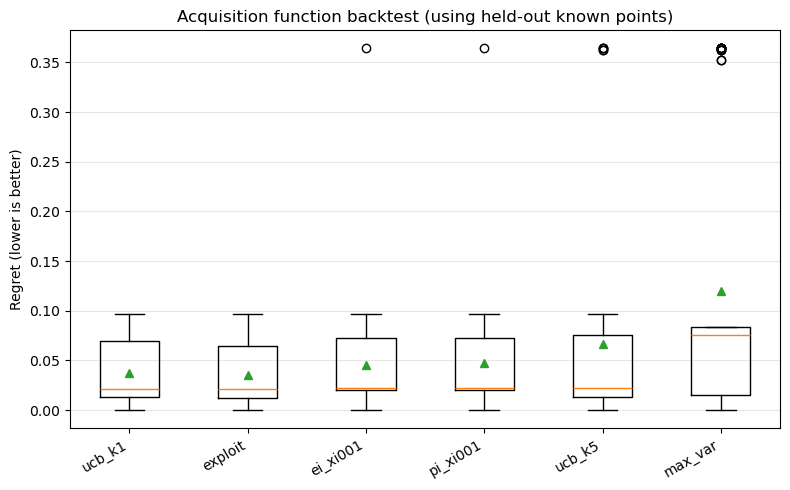

In [18]:
# xi/kappa are in raw y-units here (no y-scaling in this notebook -- see header).
backtest_configs = [
    {"name": "ei_xi001", "acquisition": "ei",  "xi": 0.01},
    {"name": "pi_xi001", "acquisition": "pi",  "xi": 0.01},
    {"name": "ucb_k1",   "acquisition": "ucb", "kappa": 1.0},
    {"name": "ucb_k5",   "acquisition": "ucb", "kappa": 5.0},
    {"name": "exploit",  "acquisition": "exploit"},
    {"name": "max_var",  "acquisition": "max_variance"},
]

with fitting("acquisition backtest, 50 splits"):
    backtest_results = backtest_acquisitions(
        X, y, bounds, backtest_configs,
        n_repeats=50, seed_frac=0.5, maximize=True,
        gp_kwargs={"n_restarts_optimizer": 15}, random_state=0,
    )

print_backtest_summary(backtest_results)

plot_acquisition_backtest(backtest_results)
plt.show()

## Sensitivity check: which dimensions actually matter

Per-dimension ARD length-scales. Short = the function varies quickly along that axis, so it matters. Pinned at the upper `length_scale_bounds` = the GP sees that axis as close to irrelevant.

**Only "pinned vs. not pinned" is trustworthy** -- don't compare two dimensions that are both pinned. Expect x0 and x1 pinned at 10.0 and only x2 short (~0.104 under this week's box bounds; ~0.056 under the wider standard bounds, since the rescale compresses the data).

This cell is load-bearing for the whole approach: the proposal below restricts its search to whichever dimensions come back non-pinned, and warns if that stops being exactly one. It also explains why the `plot_nd_slices` panels for x0 and x1 look flat -- that's the model, not a plotting bug.

In [19]:
# PINNED and `incumbent` are defined HERE, once, and reused by the EI-evidence
# and proposal cells below -- the proposal used to depend on `incumbent` being
# set in the EI cell, which made an evidence-only section load-bearing.
PINNED = 10.0  # fit_gp's default length_scale_bounds upper limit

with fitting("shared GP for the sensitivity check"):
    gp_check = fit_gp(X, y, bounds, n_restarts_optimizer=20, random_state=0)

length_scales = get_length_scales(gp_check)
incumbent = X[np.argmax(y)]

for dim, ls in sorted(enumerate(length_scales), key=lambda t: t[1]):
    pinned = ls >= 0.999 * PINNED
    tag = "<- PINNED, looks irrelevant" if pinned else (
        "(most sensitive)" if ls == length_scales.min() else "")
    print(f"x{dim}: length_scale = {ls:8.3f} {tag}")

informative = [d for d, ls in enumerate(length_scales) if ls < 0.999 * PINNED]
print("\ndimensions the GP currently treats as informative:", informative)
print(f"incumbent (best observed point): {np.round(incumbent, 4)}  y = {y.max():.4f}")

[fitting: shared GP for the sensitivity check] 2 warnings held back, 2 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
x2: length_scale =    0.110 (most sensitive)
x0: length_scale =   10.000 <- PINNED, looks irrelevant
x1: length_scale =   10.000 <- PINNED, looks irrelevant

dimensions the GP currently treats as informative: [2]
incumbent (best observed point): [0.4926 0.6116 0.3402]  y = -0.0348


## Why not EI: the xi sweep, kept as evidence

**This section no longer chooses the proposal** -- it's the record of why EI was set aside this week. `xi` is EI's improvement margin in raw `y`-units (observed spread ~0.36).

Three things to read off the table:

1. **`xi` doesn't move the proposal off the pathology.** Under the standard bounds every value from 0 to 0.35 lands 2-3 coordinates outside the observed range; under box bounds every value from 0 to 0.05 lands on essentially the same x2 (~0.855-0.859). Either way `xi` is not the dial that matters here.
2. **EI's target is model ringing.** x2 ~ 0.858 wins because the posterior mean bumps to about -0.044 there, between observations at x2=0.771 (`y = -0.118`) and x2=0.920 (`y = -0.114`). A short length-scale with a large fitted amplitude overshoots between sparse points.
3. **Its x0/x1 land on a box corner.** Every row proposes x0 ~ 0.966, x1 ~ 0.941 -- both at their maxima, which is outside the convex hull of the data even though inside the box.

Re-run this each week. If a future refit stops pinning x0/x1, or the x2 profile stops ringing, EI becomes the sensible default again and this notebook should go back to it.

[fitting: xi sweep (one shared GP)] 2 warnings held back, 2 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
      xi |                   x_next |  acq_value |  pred_mean |  pred_std |  dist_from_best
-------------------------------------------------------------------------------------------
       0 |      [0.966,0.941,0.859] |     0.0196 |    -0.0412 |    0.0567 |          0.7762
   0.002 |      [0.966,0.941,0.859] |     0.0187 |    -0.0412 |    0.0568 |          0.7761
    0.01 |      [0.966,0.941,0.859] |     0.0154 |    -0.0414 |    0.0570 |          0.7757
   0.025 |      [0.966,0.941,0.858] |     0.0104 |    -0.0418 |    0.0574 |          0.7749
    0.05 |      [0.966,0.941,0.856] |     0.0049 |    -0.0425 |    0.0579 |          0.7738


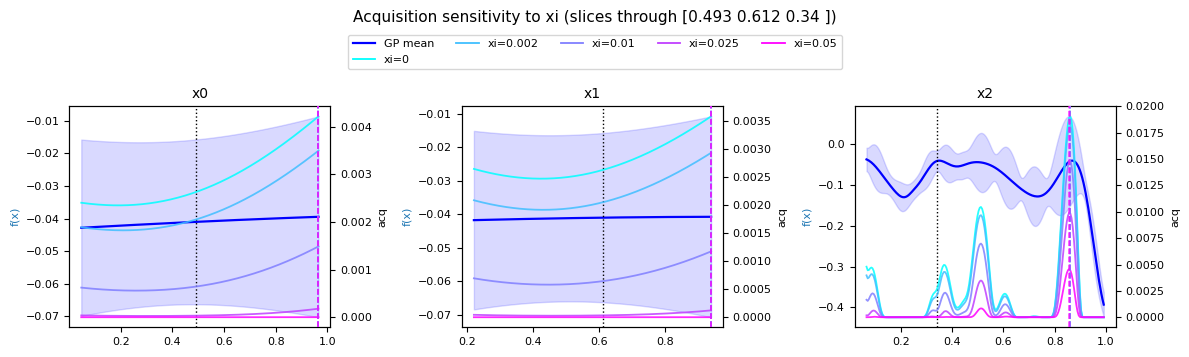


GP profile along x2 (x0/x1 held at the incumbent):
     x2 |   GP mean |  GP std |  nearest observed y
   0.10 |   -0.0537 |  0.0269 |   -0.0364 (x2=0.066)
   0.34 |   -0.0411 |  0.0129 |   -0.0348 (x2=0.340)
   0.57 |   -0.0583 |  0.0175 |   -0.0568 (x2=0.567)
   0.65 |   -0.0999 |  0.0244 |   -0.1101 (x2=0.670)
   0.67 |   -0.1101 |  0.0144 |   -0.1101 (x2=0.670)
   0.77 |   -0.1173 |  0.0180 |   -0.1180 (x2=0.771)
   0.86 |   -0.0413 |  0.0555 |   -0.1139 (x2=0.920)
   0.92 |   -0.1184 |  0.0152 |   -0.1139 (x2=0.920)
   0.99 |   -0.3912 |  0.0158 |   -0.3989 (x2=0.991)


In [20]:
with fitting("xi sweep (one shared GP)"):
    xi_rows = compare_xi_proposals(X, y, bounds,
                                   xi_values=[0.0, 0.002, 0.01, 0.025, 0.05],
                                   acquisition="ei", maximize=True, n_restarts=20,
                                   random_state=0)

print_xi_comparison(xi_rows)

plot_xi_sensitivity(X, y, bounds, gp_check, xi_rows, ei_acquisition, maximize=True)
plt.show()

# The posterior-mean bump EI is chasing, shown numerically along x2 with
# x0/x1 held at the incumbent. Note the rise between the two bracketing
# observations rather than a trend toward either of them.
print("\nGP profile along x2 (x0/x1 held at the incumbent):")
print(f"{'x2':>7} | {'GP mean':>9} | {'GP std':>7} | {'nearest observed y':>19}")
for v in [0.10, 0.34, 0.57, 0.65, 0.67, 0.77, 0.86, 0.92, 0.99]:
    p = incumbent.copy()
    p[2] = v
    m, s = gp_check.predict(normalize(p.reshape(1, -1), bounds), return_std=True)
    j = int(np.argmin(np.abs(X[:, 2] - v)))
    print(f"{v:7.2f} | {m[0]:+9.4f} | {s[0]:7.4f} | {y[j]:+9.4f} (x2={X[j, 2]:.3f})")

## Propose the next point: max-variance along the informative dimension

Three steps, in order:

1. Confirm which dimensions the GP treats as informative (recomputed here rather than assumed -- if this changes, the whole approach below should be revisited).
2. Find the unconstrained `max_variance` proposal within the box, for reference. Its x2 is the number that matters; its x0/x1 are arbitrary because the acquisition is flat along them.
3. Build the point actually submitted: x2 from a fine scan along the informative axis, x0/x1 pinned at the incumbent so the point sits inside the data cloud rather than on an arbitrary box edge.

Two checks then run on the result. The **per-axis** check (within the observed range on every dimension independently) is guaranteed by the box bounds and should never fire. The **convex-hull** check is strictly stronger and is the one that matters: a point can be in range on every axis and still sit outside the data cloud entirely. That's exactly what happens to both the unconstrained `max_variance` proposal and EI's in-box proposal -- both pass the per-axis check and fail the hull check, because they park x0/x1 at opposing box edges. The restricted construction in step 3 passes both.

In [21]:
# All GP fitting for this cell happens FIRST, so its ConvergenceWarnings cannot
# land in the middle of the three-step output below. PINNED comes from the
# sensitivity cell.
with fitting("unconstrained max_variance, for reference"):
    x_unconstrained, gp = generate_next_point(
        X, y, bounds,
        acquisition="max_variance",
        maximize=True,
        n_restarts=40,
        random_state=0,
    )

# --- 1. Which dimensions does the GP actually use? -------------------------
informative = [d for d, ls in enumerate(get_length_scales(gp_check)) if ls < 0.999 * PINNED]
flat = [d for d in range(D) if d not in informative]
print("informative dimensions:", informative, "| flat (pinned) dimensions:", flat)

if len(informative) != 1:
    print("\n*** The 'one informative axis' assumption no longer holds. ***")
    print("Re-read the header: the restricted-search construction below was")
    print("justified by exactly one non-pinned dimension. Reconsider before using.")

# --- 2. Unconstrained max_variance within the box, for reference -----------
# (fitted above, before any printing)
mu_u, sd_u = gp.predict(normalize(x_unconstrained.reshape(1, -1), bounds), return_std=True)
print(f"\nunconstrained max_variance: {np.round(x_unconstrained, 4)}"
      f"  mean={mu_u[0]:+.4f} std={sd_u[0]:.4f}")
print(f"  in convex hull of the data: {hull.find_simplex(x_unconstrained) >= 0}")
print("  (its x0/x1 are arbitrary -- the acquisition is flat along them)")

# --- 3. The point actually proposed ---------------------------------------
# Scan the informative axis at fine resolution, holding the flat axes at the
# incumbent. Uses the same acquisition as step 2, so the two are comparable.
DIM = informative[0] if len(informative) == 1 else int(np.argmin(get_length_scales(gp_check)))
scan = np.tile(incumbent, (2000, 1))
scan[:, DIM] = np.linspace(bounds[DIM, 0], bounds[DIM, 1], 2000)
scan_norm = normalize(scan, bounds)
acq_vals = max_variance_acquisition(scan_norm, gp)

x_next = scan[int(np.argmax(acq_vals))]
mu, sigma = gp.predict(normalize(x_next.reshape(1, -1), bounds), return_std=True)

print(f"\n--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print("x_next:", np.round(x_next, 6))
print(gp.kernel_)
print(f"GP predicted mean: {mu[0]:.4g}, predicted std: {sigma[0]:.4g}")

drift = abs(x_next[DIM] - x_unconstrained[DIM])
print(f"\nx{DIM} agreement between constrained and unconstrained: "
      f"{x_next[DIM]:.4f} vs {x_unconstrained[DIM]:.4f} (drift {drift:.4f})")
if drift > 0.05:
    print("*** They disagree. The flat-axis assumption may have broken down -- check before submitting. ***")

# --- Safety checks --------------------------------------------------------
# Weak check: within the observed range on every axis independently. Box
# bounds guarantee this, so it should never fire.
on_edge = [d for d in range(D)
           if np.isclose(x_next[d], bounds[d, 0]) or np.isclose(x_next[d], bounds[d, 1])]
outside = [d for d in range(D) if not (X[:, d].min() <= x_next[d] <= X[:, d].max())]
print("\ndimensions where x_next sits on a bound:", on_edge or "none")
print("dimensions where x_next is outside the observed data range:", outside or "none")

# Strong check: inside the actual convex hull of the observations. This is
# strictly harder than the per-axis check above -- a box corner can pass that
# and fail this -- and it's the real test of "interpolation, not extrapolation".
in_hull = bool(hull.find_simplex(x_next) >= 0)
print(f"\nx_next inside the CONVEX HULL of the observations: {in_hull}")
if not in_hull:
    print("*** x_next is within range on every axis but outside the data cloud. ***")
    print("    That is still extrapolation. Consider moving the flat coordinates")
    print("    further toward the centre of the data before submitting.")

# Which observations bracket the proposal along the informative axis? The
# point is informative precisely because these two disagree.
below = X[X[:, DIM] <= x_next[DIM]]
above = X[X[:, DIM] >= x_next[DIM]]
y_below = y[X[:, DIM] <= x_next[DIM]]
y_above = y[X[:, DIM] >= x_next[DIM]]
if len(below) and len(above):
    lo_i, hi_i = int(np.argmax(below[:, DIM])), int(np.argmin(above[:, DIM]))
    print(f"\nbracketing observations along x{DIM}:")
    print(f"  below: x{DIM}={below[lo_i, DIM]:.3f}  y={y_below[lo_i]:+.4f}")
    print(f"  above: x{DIM}={above[hi_i, DIM]:.3f}  y={y_above[hi_i]:+.4f}")
    print(f"  gap width: {above[hi_i, DIM] - below[lo_i, DIM]:.3f}")

[fitting: unconstrained max_variance, for reference] 2 warnings held back, 2 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
informative dimensions: [2] | flat (pinned) dimensions: [0, 1]

unconstrained max_variance: [0.966  0.9414 0.843 ]  mean=-0.0503 std=0.0597
  in convex hull of the data: False
  (its x0/x1 are arbitrary -- the acquisition is flat along them)

--- Next point to evaluate (bounds shape (3, 2)) ---
x_next: [0.492581 0.611593 0.843766]
1.48**2 * Matern(length_scale=[10, 10, 0.11], nu=2.5) + WhiteKernel(noise_level=0.0162)
GP predicted mean: -0.05006, predicted std: 0.05853

x2 agreement between constrained and unconstrained: 0.8438 vs 0.8430 (drift 0.0007)

dimensions where x_next sits on a bound: none
dimensions where x_next is outside the observed data range: none

x_next inside the CONVEX HULL of the observations: False
*** x_next is

## Visualise the GP and acquisition function via 1D slices

Each panel holds the other two dimensions fixed at the current best observed point and sweeps one dimension. Dotted line is the fixed centre, dashed red is the proposed `x_next`. The green acquisition curve is `max_variance`, i.e. the posterior std itself.

This is a *partial* view: it shows what the GP believes along each axis near the best point, not interactions between dimensions. Two things to expect:

- The **x0 and x1 panels are flat** -- both the GP mean and the acquisition. That's the pinned length-scales, not a plotting bug, and it's the whole reason the proposal fixes those coordinates at the incumbent instead of optimising them.
- The **x2 panel** should show the acquisition peaking in the 0.567-0.771 gap, where `x_next` sits, with visible ringing in the mean between sparse observations.

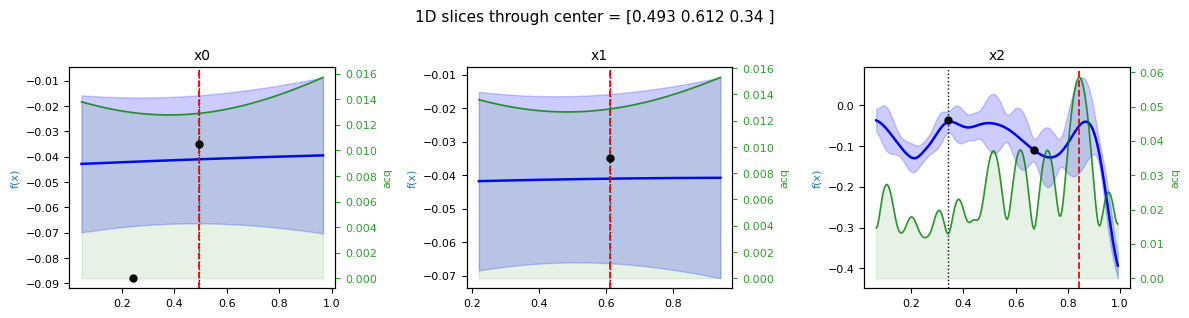

In [22]:
# max_variance_acquisition takes no extra kwargs -- it's just the posterior std.
plot_nd_slices(
    X, y, bounds, gp,
    acquisition_fn=max_variance_acquisition,
    x_next=x_next,
    acq_kwargs={},
)
plt.show()

## Sanity-check the surrogate model: leave-one-out calibration

Refits the GP once per observation, leaving it out, and predicts it from the rest. This matters more here than in 1D/2D, since you can no longer just look at the fitted surface and eyeball whether it's reasonable.

At 16 points the thing to read is whether the error bars cover the diagonal, not how tight the correlation is. Pay particular attention to the one strong outlier in this batch (`y = -0.399`, against a median around -0.10) -- if the GP can't predict it when held out, that's expected rather than alarming, but it does mean the surrogate is weak in whatever region that point occupies.

[fitting: leave-one-out calibration] 33 warnings held back, 3 distinct:
    17 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
    15 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06


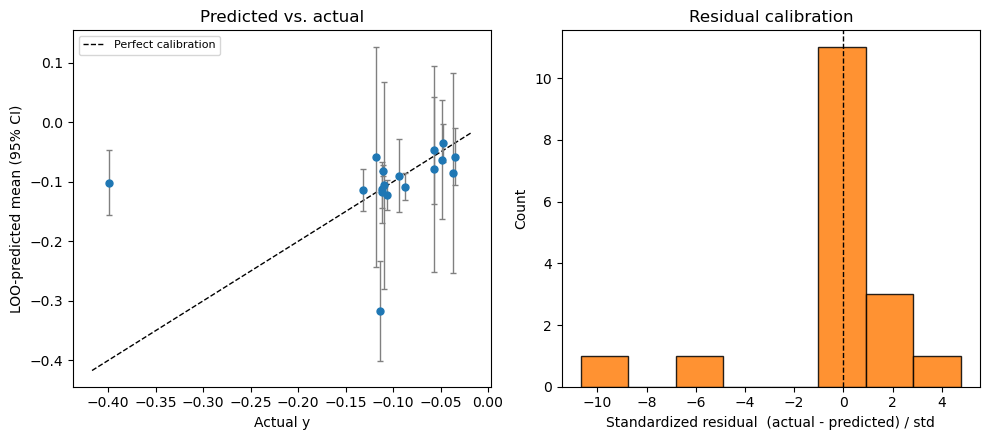

points inside their own 95% LOO interval: 14/17


In [23]:
with fitting("leave-one-out calibration"):
    pred_mean, pred_std = loo_predictions(X, y, bounds,
                                          gp_kwargs={"n_restarts_optimizer": 20})

plot_loo_calibration(y, pred_mean, pred_std)
plt.show()

within = np.abs(y - pred_mean) <= 1.96 * pred_std
print(f"points inside their own 95% LOO interval: {within.sum()}/{len(y)}")

## Iteration diagnostics

`compute_iteration_diagnostics` replays the ordered `X`/`y` to reconstruct what the acquisition value, GP hyperparameters, and domain-wide uncertainty were at each past proposal -- no persisted log involved.

It applies **one** acquisition setting to the whole history, which is normally a hazard when the history is mixed (the single recorded observation here was proposed under the old notebook's `pi`/`xi=0.01`). Replaying with `max_variance` sidesteps that: its acquisition value is just the posterior std at the point *before* it was evaluated, which is a meaningful quantity however that point was chosen. So the `acq_value` column below reads as "how uncertain was the model there beforehand" and is interpretable across the mix.

Two caveats that still apply: it assumes row order is true chronological order, and it uses the bounds passed in -- which are this week's observed bounding box, so `domain_mean_std` is the mean uncertainty over that box, not over the standard padded box. Don't compare those numbers against a week that used different bounds.

`plot_bo_diagnostics` is skipped: it hard-codes a 2D scatter panel and this is a 3D problem. The individual trend plots below are dimension-agnostic, and need a few completed iterations before any trend is readable, so they're gated.

In [24]:
# The old `if len(new_y) == 0` guard is gone: new_y is populated above, so that
# branch was unreachable. Restore it only if this notebook is reset to a bare
# initial batch. Fitting happens first so the warnings can't split the output.
with fitting("iteration-diagnostics replay"):
    history = compute_iteration_diagnostics(X, y, bounds, n_initial=n_initial,
                                            acquisition="max_variance", maximize=True)

print("Best y so far:", np.nanmax(history["y"]))
print("completed iterations beyond the initial batch:", len(new_y))

if len(new_y) >= 3:
    for plot_fn in (plot_convergence, plot_acquisition_decay,
                    plot_uncertainty_shrinkage, plot_step_distance):
        plot_fn(history)
        plt.show()
else:
    print(f"\nOnly {len(new_y)} completed iteration(s) -- need at least 3 for the trend")
    print("plots to say anything. Skipping them; the raw fields are below.")

[fitting: iteration-diagnostics replay] 4 warnings held back, 2 distinct:
     2 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
     2 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
Best y so far: -0.034835313350078584
completed iterations beyond the initial batch: 2

Only 2 completed iteration(s) -- need at least 3 for the trend
plots to say anything. Skipping them; the raw fields are below.


## Raw diagnostic fields

In [25]:
print("y:", history["y"])
print("\niteration:", history["iteration"])
print("\nacq_value (NaN = initial batch; see the caveat above):", history["acq_value"])
print("\ndomain_mean_std:", history["domain_mean_std"])

y: [-0.1121222  -0.08796286 -0.11141465 -0.03483531 -0.04800758 -0.11062091
 -0.39892551 -0.11386851 -0.13146061 -0.09418956 -0.04694741 -0.10596504
 -0.11804826 -0.03637783 -0.05675837 -0.05641777 -0.11005965]

iteration: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 2.]

acq_value (NaN = initial batch; see the caveat above): [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan 0.04895409 0.08871425]

domain_mean_std: [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan 0.03936493 0.03374035]


In [26]:
# The proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision as well. 6 dp is fine to submit, but paste THIS into next
# week's new_X: a 6-dp copy of function 4's proposal rounded 4e-7 outside its
# own upper bound and tripped validate_bounds_consistency.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))

0.492581-0.611593-0.843766

full precision (use for next week's new_X):
0.49258141463713434-0.6115931882759961-0.8437661859335256
